### Imports

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
import torch
from transformers import AutoTokenizer, AutoModel
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

### Read & Clean Twitter Data in Chunks

In [26]:
file_path = r"E:\Csci_3\subjects_AND_sampling_metadata_anonymized_full.csv"
chunk_size = 100000

cols_needed = [
    "clean...state_simple",
    "created_at.users",
    "tweets_historical",
    "sampling_tweet",  # text column
    "entities.hashtags.subject_pool",
    "public_metrics.like_count",
    "public_metrics.retweet_count.tweets_historical"
]

df_list = []
for chunk in pd.read_csv(file_path,
                         chunksize=chunk_size,
                         usecols=lambda x: x in cols_needed,
                         dtype=str,
                         low_memory=False):
    chunk = chunk.dropna(subset=["created_at.users", "clean...state_simple", "sampling_tweet"])
    chunk["date"] = pd.to_datetime(chunk["created_at.users"], errors="coerce")
    chunk["like_count"] = pd.to_numeric(chunk["public_metrics.like_count"], errors="coerce")
    chunk["retweet_count"] = pd.to_numeric(chunk["public_metrics.retweet_count.tweets_historical"], errors="coerce")
    df_list.append(chunk)

df = pd.concat(df_list, ignore_index=True)
swing_states = ["Arizona", "Georgia", "Michigan", "Nevada", "North Carolina", "Pennsylvania", "Wisconsin"]
df = df[df["clean...state_simple"].isin(swing_states)]

### Aggregate Daily Engagement & Spike Features

In [32]:
state_daily = df.groupby(["clean...state_simple", "date"]).agg({
    "like_count": "mean",
    "retweet_count": "mean",
    "tweets_historical": "count",
    "entities.hashtags.subject_pool": lambda x: x.notna().sum()
}).reset_index()

state_daily = state_daily[state_daily["date"] >= "2024-01-01"].copy()

# Reset index
state_daily.reset_index(drop=True, inplace=True)

state_daily.rename(columns={
    "tweets_historical": "tweet_volume",
    "entities.hashtags.subject_pool": "hashtag_count"
}, inplace=True)

# Engagement metrics
state_daily["engagement_score"] = state_daily["like_count"].fillna(0) + state_daily["retweet_count"].fillna(0)
state_daily["engagement_per_tweet"] = state_daily["engagement_score"] / state_daily["tweet_volume"].replace(0, np.nan)
state_daily["engagement_baseline"] = state_daily.groupby("clean...state_simple")["engagement_per_tweet"]\
                                              .transform(lambda x: x.rolling(7, min_periods=3).mean())
state_daily["engagement_spike"] = state_daily["engagement_per_tweet"] - state_daily["engagement_baseline"]
threshold = state_daily["engagement_spike"].quantile(0.75)
state_daily["high_spike"] = (state_daily["engagement_spike"] > threshold).astype(int)

### Event Features (5 Campaign Events)

In [33]:
events = {
    "Event1": "2024-01-01",
    "Event2": "2024-06-01",
    "Event3": "2024-07-13",
    "Event4": "2024-07-21",
    "Event5": "2024-10-20"
}

state_daily["date"] = pd.to_datetime(state_daily["date"], utc=True)

for key, date in events.items():
    event_date = pd.to_datetime(date, utc=True)
    state_daily[f"{key}_days_since"] = (state_daily["date"] - event_date).dt.days
    state_daily[f"{key}_post"] = ((state_daily[f"{key}_days_since"] > 0) &
                                   (state_daily[f"{key}_days_since"] <= 15)).astype(int)
    
    # Top 50% spike = treated
    temp = state_daily[(state_daily[f"{key}_days_since"] >= 0) & (state_daily[f"{key}_days_since"] <= 3)]
    spike_by_state = temp.groupby("clean...state_simple")["engagement_spike"].mean()
    treated_states = spike_by_state[spike_by_state > spike_by_state.quantile(0.5)].index
    state_daily[f"{key}_treated"] = state_daily["clean...state_simple"].isin(treated_states).astype(int)
    
    # Interaction term
    state_daily[f"{key}_interaction"] = state_daily[f"{key}_treated"] * state_daily[f"{key}_post"]

### NLP Feature Extraction

In [34]:
# Aggregate all tweets per state-day for topic modeling
state_text = df.groupby(["clean...state_simple", "date"])["sampling_tweet"].apply(lambda x: " ".join(x)).reset_index()

vectorizer = CountVectorizer(max_features=1000, stop_words="english")
doc_term_matrix = vectorizer.fit_transform(state_text["sampling_tweet"])

lda = LatentDirichletAllocation(n_components=10, random_state=42)
lda_topics = lda.fit_transform(doc_term_matrix)

# Add topics as features
for i in range(10):
    state_text[f"topic_{i}"] = lda_topics[:, i]

state_daily = state_daily.merge(state_text.drop(columns=["sampling_tweet"]), on=["clean...state_simple", "date"], how="left")

### Predict Synthetic Poll Trajectory from Twitter Signals

In [35]:
# Interaction terms (DiD logic)
interaction_terms = [f"{e}_interaction" for e in events.keys()]

# Topic features from LDA (10 topics)
topic_features = [f"topic_{i}" for i in range(10)]

# Base Twitter metrics
twitter_features = ["engagement_per_tweet", "tweet_volume"]

# Combine all predictors
predictors = twitter_features + interaction_terms + topic_features

# Prepare X and y
X = state_daily[predictors].fillna(0)

# Target: next-day engagement or poll proxy (shifted)
y = state_daily["engagement_per_tweet"].shift(-1).fillna(0) 

### Visualize Trajectory & Geographic Bias

Estimated DiD effects per event:
    Event      DiD_coef
0  Event1 -6.586528e-18
1  Event2  1.409463e-18
2  Event3 -2.815538e-18
3  Event4 -5.637851e-18
4  Event5 -2.710505e-18


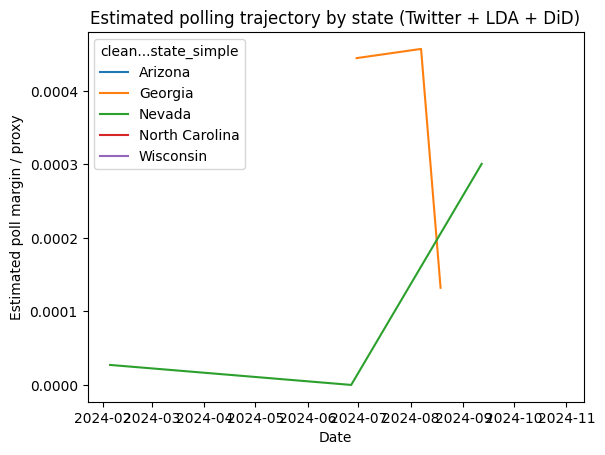

In [36]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X, y)

# Predicted polling trajectory
state_daily["poll_estimated"] = model.predict(X)

# ================================
# STEP: Check DiD contributions
# ================================
did_effects = pd.DataFrame({
    "Event": events.keys(),
    "DiD_coef": [model.coef_[predictors.index(f"{e}_interaction")] for e in events.keys()]
})

print("Estimated DiD effects per event:")
print(did_effects)

# ================================
# STEP: Plot predicted polling trajectory per state
# ================================
import matplotlib.pyplot as plt
import seaborn as sns

sns.lineplot(data=state_daily, x="date", y="poll_estimated", hue="clean...state_simple")
plt.title("Estimated polling trajectory by state (Twitter + LDA + DiD)")
plt.ylabel("Estimated poll margin / proxy")
plt.xlabel("Date")
plt.show()